# RL & MDP Project: LunarLander


In [46]:
import numpy as np
import gymnasium as gym
import imageio
from base64 import b64encode
from IPython.display import HTML

ENV_IDS = ["LunarLander-v3", "LunarLander-v2"]


def make_lander_env(render_mode=None):
    last_error = None
    for env_id in ENV_IDS:
        try:
            if render_mode is None:
                env = gym.make(env_id)
            else:
                env = gym.make(env_id, render_mode=render_mode)
            print(f"Using env_id={env_id!r}, render_mode={render_mode!r}")
            return env
        except Exception as e:
            last_error = e
    raise RuntimeError(
        f"Could not create any LunarLander environment from {ENV_IDS}: {last_error}"
    )


def record_video(
    env,
    policy,
    out_directory,
    fps=30,
    random_action=False,
    max_steps=1600,
    action_set=None,
):
    images = []
    total_reward = 0.0
    terminated = False
    truncated = False

    obs, info = env.reset()
    img = env.render()
    images.append(img)

    t = 0
    while not (terminated or truncated):
        t += 1
        if t > max_steps:
            break

        if random_action:
            if action_set is not None:
                idx = np.random.randint(len(action_set))
                action = np.array(action_set[idx], dtype=np.float32)
            else:
                action = env.action_space.sample()
        else:
            act = policy(obs)
            if action_set is not None:
                idx = int(act)
                action = np.array(action_set[idx], dtype=np.float32)
            else:
                if hasattr(env.action_space, "n"):
                    action = int(act)
                else:
                    action = np.array(act, dtype=np.float32)

        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += float(reward)

        img = env.render()
        images.append(img)

    imageio.mimsave(out_directory, images, fps=fps)
    return total_reward


def show_video(video_path, video_width=500):
    video_file = open(video_path, "r+b").read()
    video_url = f"data:video/mp4;base64,{b64encode(video_file).decode()}"
    return HTML(
        f'<video width="{video_width}" controls>'
        f'<source src="{video_url}" type="video/mp4"></video>'
    )

## 1. LunarLander setup and random baseline

In this section you will:

1. Create a LunarLander environment from Gymnasium.
2. Inspect observation and action spaces.
3. Run a simple random policy baseline.
4. Record a short video of a random agent using the provided helpers.


In [47]:
# TODO 1.1: Create a training environment (no render_mode)
train_env = make_lander_env()

# TODO 1.2: Create a separate environment for video recording (render_mode="rgb_array")
video_env = make_lander_env(render_mode="rgb_array")

# TODO 1.3: Reset training env and inspect spaces
obs, info = train_env.reset()

print("Initial observation:", obs)
print("Observation shape:", obs.shape)
print("Action space:", train_env.action_space)


Using env_id='LunarLander-v2', render_mode=None
Using env_id='LunarLander-v2', render_mode='rgb_array'
Initial observation: [-0.00518217  1.41686    -0.52491033  0.26396975  0.00601161  0.11890006
  0.          0.        ]
Observation shape: (8,)
Action space: Discrete(4)


In [48]:
def run_random_policy(env, num_episodes, max_steps):
    returns = []
    for ep in range(num_episodes):
        # TODO 1.4: reset the environment
        obs, info = env.reset()
        
        total_reward = 0.0
        for t in range(max_steps):
            # TODO 1.5: sample a random action from env.action_space
            action = env.action_space.sample()
            
            # TODO 1.6: step the environment and accumulate reward
            obs, reward, terminated, truncated, info = env.step(action)
            total_reward += reward
            
            if terminated or truncated:
                break

        returns.append(total_reward)
    return returns


random_returns = run_random_policy(
    train_env,
    num_episodes=100,
    max_steps=500
)

print(
    "Random policy: mean return =",
    np.mean(random_returns),
    "±",
    np.std(random_returns)
)


Random policy: mean return = -157.31299780647677 ± 101.45368525078611


In [75]:
# TODO === 1.3 Record a random policy video ===

# مسیر خروجی ویدیو
video_path = "random_policy_lunarlander.mp4"

# ضبط ویدیو با استفاده از تابع record_video و سیاست تصادفی
record_video(
    env=video_env,
    policy=lambda obs: video_env.action_space.sample(),  # random policy
    out_directory=video_path,
    fps=30,
    random_action=True,
    max_steps=500
)

# نمایش ویدیو داخل Notebook
show_video(video_path)


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 400) to (608, 400) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


## 2. A small finite MDP

To practice Iterative Policy Evaluation and Policy Iteration, we will use a small tabular MDP

In [76]:
def build_gridworld_mdp():
    # ابعاد Gridworld
    n_rows, n_cols = 4, 4  # 4x4 Gridworld
    n_states = n_rows * n_cols
    n_actions = 4  # up=0, right=1, down=2, left=3

    # Transition probabilities P[s, a, s'] و جوایز R[s, a, s']
    P = np.zeros((n_states, n_actions, n_states))
    R = np.zeros((n_states, n_actions, n_states))

    # حالت‌های پایانی: گوشه بالا-چپ و پایین-راست
    terminal_states = [0, n_states - 1]

    # تابع کمکی: تبدیل (row, col) به index حالت
    def to_state(r, c):
        return r * n_cols + c

    # تابع کمکی: حرکت و محدودیت
    def move(r, c, action):
        if action == 0:  # up
            r = max(r - 1, 0)
        elif action == 1:  # right
            c = min(c + 1, n_cols - 1)
        elif action == 2:  # down
            r = min(r + 1, n_rows - 1)
        elif action == 3:  # left
            c = max(c - 1, 0)
        return r, c

    # پر کردن P و R
    for r in range(n_rows):
        for c in range(n_cols):
            s = to_state(r, c)
            for a in range(n_actions):
                # اگر حالت پایانی باشد، خودش می‌ماند
                if s in terminal_states:
                    P[s, a, s] = 1.0
                    R[s, a, s] = 0.0
                else:
                    r_next, c_next = move(r, c, a)
                    s_next = to_state(r_next, c_next)
                    P[s, a, s_next] = 1.0
                    # پاداش -1 برای هر حرکت، 0 در حالت پایانی
                    R[s, a, s_next] = -1.0 if s_next not in terminal_states else 0.0

    return n_states, n_actions, P, R, terminal_states


# ساخت MDP
n_states, n_actions, P, R, terminal_states = build_gridworld_mdp()

print("Gridworld: n_states =", n_states, "| n_actions =", n_actions)
print("Terminal states:", terminal_states)


Gridworld: n_states = 16 | n_actions = 4
Terminal states: [0, 15]


### 2.1 Policy representation and Iterative Policy Evaluation

We represent a policy $\pi(a \mid s)$ as a 2D NumPy array of shape `[n_states, n_actions]`,
where each row is a probability distribution over actions in that state.

**Tasks:**

1. Define an **initial policy** that is **uniform over all actions** in non-terminal states.
2. Implement **Iterative Policy Evaluation**:

   $$V_{k+1}(s) = \sum_a \pi(a\mid s) \sum_{s'} P(s' \mid s, a) \left[R(s,a,s') + \gamma V_k(s') \right]$$

   Stop when the maximum change `delta` over all states is below a small threshold `theta`.

In [77]:
# discount factor
gamma_grid = 0.99

# TODO 2.1: Define an initial uniform policy over actions (for non-terminal states)
policy = np.zeros((n_states, n_actions), dtype=np.float32)

for s in range(n_states):
    if s in terminal_states:
        policy[s, :] = 0.0
    else:
        policy[s, :] = 1.0 / n_actions


def iterative_policy_evaluation(policy, P, R, gamma=0.99, theta=1e-6):
    n_states, n_actions, _ = P.shape
    V = np.zeros(n_states, dtype=np.float32)

    while True:
        delta = 0.0
        for s in range(n_states):
            if s in terminal_states:
                continue

            v_old = V[s]
            v_new = 0.0

            for a in range(n_actions):
                for s_next in range(n_states):
                    v_new += policy[s, a] * P[s, a, s_next] * (
                        R[s, a, s_next] + gamma * V[s_next]
                    )

            V[s] = v_new
            delta = max(delta, abs(v_old - v_new))

        if delta < theta:
            break

    return V


# TODO: After implementing both policy and iterative_policy_evaluation, uncomment:
V_pi = iterative_policy_evaluation(policy, P, R, gamma=gamma_grid, theta=1e-6)

print("Value function under uniform policy (reshaped 4x4):")
print(V_pi.reshape(4, 4))


Value function under uniform policy (reshaped 4x4):
[[  0.       -11.055761 -16.12231  -17.783255]
 [-11.055761 -14.461367 -16.13892  -16.12231 ]
 [-16.12231  -16.13892  -14.461367 -11.055761]
 [-17.783255 -16.12231  -11.055761   0.      ]]


### 2.2 Policy Improvement and Policy Iteration

We now implement:

1. **Policy Improvement**: given $V(s)$, compute a greedy policy:
   $$\pi_{\text{greedy}}(s) = \arg\max_a \sum_{s'} P(s' \mid s,a) \left[ R(s,a,s') + \gamma V(s') \right]$$

2. **Policy Iteration**: alternate between policy evaluation and policy improvement until the policy stops changing.

In [78]:
def policy_improvement(V, P, R, gamma=0.99):
    n_states, n_actions, _ = P.shape
    new_policy = np.zeros((n_states, n_actions), dtype=np.float32)

    for s in range(n_states):
        if s in terminal_states:
            continue

        q_values = np.zeros(n_actions, dtype=np.float32)

        for a in range(n_actions):
            for s_next in range(n_states):
                q_values[a] += P[s, a, s_next] * (
                    R[s, a, s_next] + gamma * V[s_next]
                )

        best_action = np.argmax(q_values)
        new_policy[s, best_action] = 1.0

    return new_policy


def policy_iteration(P, R, gamma=0.99, theta=1e-6, max_iterations=1000):
    n_states, n_actions, _ = P.shape

    # initial uniform random policy
    policy = np.zeros((n_states, n_actions), dtype=np.float32)
    for s in range(n_states):
        if s in terminal_states:
            policy[s, :] = 0.0
        else:
            policy[s, :] = 1.0 / n_actions

    for i in range(max_iterations):
        # Policy Evaluation
        V = iterative_policy_evaluation(policy, P, R, gamma=gamma, theta=theta)

        # Policy Improvement
        new_policy = policy_improvement(V, P, R, gamma=gamma)

        # Check convergence
        if np.array_equal(new_policy, policy):
            print(f"Policy iteration converged after {i+1} iterations.")
            break

        policy = new_policy

    return policy, V


# TODO: After implementing policy_improvement and policy_iteration, uncomment:
policy_star, V_star = policy_iteration(P, R, gamma=gamma_grid, theta=1e-6)

print("Optimal value function (4x4):")
print(V_star.reshape(4, 4))

print("Optimal policy (action indices, 4x4):")
print(np.argmax(policy_star, axis=1).reshape(4, 4))


Policy iteration converged after 3 iterations.
Optimal value function (4x4):
[[ 0.    0.   -1.   -1.99]
 [ 0.   -1.   -1.99 -1.  ]
 [-1.   -1.99 -1.    0.  ]
 [-1.99 -1.    0.    0.  ]]
Optimal policy (action indices, 4x4):
[[0 3 3 2]
 [0 0 0 2]
 [0 0 1 2]
 [0 1 1 0]]


## 3. Tabular Q-Learning on LunarLander (with discretized state)

LunarLander has a **continuous state space**, so we cannot directly store a Q-table indexed by states.

We will:

1. **Discretize the 8-dimensional state vector** into a finite number of bins per dimension.
2. Maintain a **Q-table** `Q[discrete_state, action]`.
3. Implement **tabular Q-Learning**:

   $$Q(s,a) \leftarrow (1-\alpha) Q(s,a) + \alpha \left[ r + \gamma \max_{a'} Q(s',a') \right]$$

4. Train a policy and compare its returns to the random baseline.

In [79]:
obs_low = train_env.observation_space.low
obs_high = train_env.observation_space.high
print("Observation low:", obs_low)
print("Observation high:", obs_high)

n_actions_lander = train_env.action_space.n
print("Number of discrete actions:", n_actions_lander)

num_bins = np.array([6, 6, 6, 6, 6, 6, 2, 2], dtype=int)

# TODO 3.1: Create bin boundaries for each dimension
def create_bins(obs_low, obs_high, num_bins):
    bins = []
    for i in range(len(num_bins)):
        if num_bins[i] == 2:
            # binary features (leg contact)
            bins.append(np.array([0.5]))
        else:
            bins.append(
                np.linspace(obs_low[i], obs_high[i], num_bins[i] + 1)[1:-1]
            )
    return bins


bins = create_bins(obs_low, obs_high, num_bins)

# TODO 3.2: Discretize a continuous observation into a tuple of indices
def discretize_observation(obs, bins):
    discrete_state = []
    for i in range(len(obs)):
        idx = np.digitize(obs[i], bins[i])
        discrete_state.append(idx)
    return tuple(discrete_state)


test_state = discretize_observation(obs, bins)
print("Example discrete state:", test_state)


Observation low: [-1.5       -1.5       -5.        -5.        -3.1415927 -5.
 -0.        -0.       ]
Observation high: [1.5       1.5       5.        5.        3.1415927 5.        1.
 1.       ]
Number of discrete actions: 4
Example discrete state: (np.int64(2), np.int64(5), np.int64(2), np.int64(3), np.int64(3), np.int64(3), np.int64(0), np.int64(0))


In [80]:
alpha = 0.1
gamma_q = 0.99
epsilon_start = 1.0
epsilon_end = 0.05
epsilon_decay = 0.999
num_episodes = 2000
max_steps_per_episode = 1000

state_shape = tuple(num_bins)
q_table = np.zeros(state_shape + (n_actions_lander,), dtype=np.float32)


# TODO 3.3: epsilon-greedy action selection
def epsilon_greedy_action(q_table, state, epsilon, n_actions):
    if np.random.rand() < epsilon:
        return np.random.randint(n_actions)
    else:
        return np.argmax(q_table[state])


# TODO 3.4: Q-Learning training loop
def q_learning_train(env, bins, num_bins, num_episodes=2000, max_steps=1000,
                     alpha=0.1, gamma=0.99,
                     epsilon_start=1.0, epsilon_end=0.05, epsilon_decay=0.995):

    n_actions = env.action_space.n
    q_table = np.zeros(tuple(num_bins) + (n_actions,), dtype=np.float32)

    episode_returns = []
    epsilon = epsilon_start

    for ep in range(num_episodes):
        obs, info = env.reset()
        state = discretize_observation(obs, bins)

        total_reward = 0.0

        for t in range(max_steps):
            action = epsilon_greedy_action(q_table, state, epsilon, n_actions)

            next_obs, reward, terminated, truncated, info = env.step(action)
            next_state = discretize_observation(next_obs, bins)

            best_next_q = np.max(q_table[next_state])

            # Q-learning update
            q_table[state][action] = (
                (1 - alpha) * q_table[state][action]
                + alpha * (reward + gamma * best_next_q)
            )

            state = next_state
            total_reward += reward

            if terminated or truncated:
                break

        episode_returns.append(total_reward)

        epsilon = max(epsilon_end, epsilon * epsilon_decay)

        if (ep + 1) % 100 == 0:
            print(f"Episode {ep+1}/{num_episodes}, Return={total_reward:.2f}, Epsilon={epsilon:.3f}")

    return q_table, episode_returns


q_table, episode_returns = q_learning_train(
    train_env, bins, num_bins,
    num_episodes=num_episodes,
    max_steps=max_steps_per_episode,
    alpha=alpha,
    gamma=gamma_q,
    epsilon_start=epsilon_start,
    epsilon_end=epsilon_end,
    epsilon_decay=epsilon_decay,
)


Episode 100/2000, Return=-111.70, Epsilon=0.905
Episode 200/2000, Return=-201.31, Epsilon=0.819
Episode 300/2000, Return=-180.13, Epsilon=0.741
Episode 400/2000, Return=-68.36, Epsilon=0.670
Episode 500/2000, Return=-82.22, Epsilon=0.606
Episode 600/2000, Return=-34.28, Epsilon=0.549
Episode 700/2000, Return=-59.07, Epsilon=0.496
Episode 800/2000, Return=-305.05, Epsilon=0.449
Episode 900/2000, Return=-195.53, Epsilon=0.406
Episode 1000/2000, Return=-125.74, Epsilon=0.368
Episode 1100/2000, Return=36.26, Epsilon=0.333
Episode 1200/2000, Return=-108.87, Epsilon=0.301
Episode 1300/2000, Return=-9.35, Epsilon=0.272
Episode 1400/2000, Return=-72.62, Epsilon=0.246
Episode 1500/2000, Return=-136.97, Epsilon=0.223
Episode 1600/2000, Return=-63.81, Epsilon=0.202
Episode 1700/2000, Return=6.23, Epsilon=0.183
Episode 1800/2000, Return=112.64, Epsilon=0.165
Episode 1900/2000, Return=-100.76, Epsilon=0.149
Episode 2000/2000, Return=2.97, Epsilon=0.135


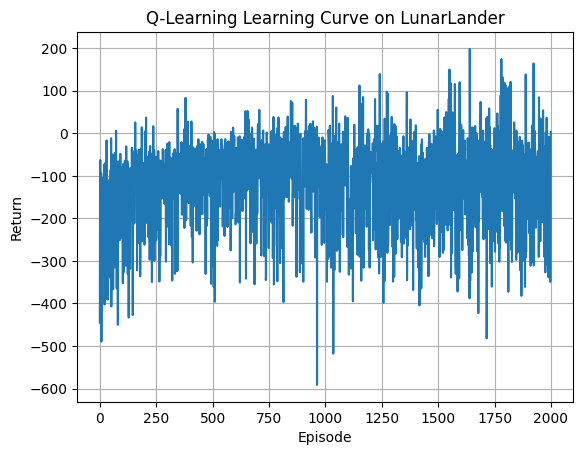

In [81]:
import matplotlib.pyplot as plt

# TODO 3.5: Plot learning curve once you have episode_returns
plt.figure()
plt.plot(episode_returns)
plt.xlabel("Episode")
plt.ylabel("Return")
plt.title("Q-Learning Learning Curve on LunarLander")
plt.grid(True)
plt.show()


In [82]:
# TODO 3.6: deterministic greedy policy from q_table
def q_table_greedy_policy(q_table, bins):
    def policy(obs):
        state = discretize_observation(obs, bins)
        return np.argmax(q_table[state])
    return policy


In [83]:
# TODO === 3.7 Record a learned (greedy) policy video ===

# ساخت سیاست حریصانه از Q-table
greedy_policy = q_table_greedy_policy(q_table, bins)

# مسیر ذخیره ویدیو
video_path_q = "q_learning_lunarlander.mp4"

# ضبط ویدیو از اجرای سیاست یادگرفته‌شده
record_video(
    env=video_env,
    policy=greedy_policy,
    out_directory=video_path_q,
    fps=30,
    random_action=False,
    max_steps=1000
)

# نمایش ویدیو
show_video(video_path_q)


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 400) to (608, 400) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
